# LIMIT: Hybrid IR Analysis, Ablations, and Insights

This notebook demonstrates the complete experiment workflow for the LIMIT project:
- Theoretical context and motivation
- Data loading and configuration
- Baseline hybrid retrieval (BM25 + SPLADE + Dense) with cross-encoder reranking
- Fusion strategy comparisons (weighted sum vs RRF; different normalizers)
- Embedding-dimension ablation experiments and plots
- Query planning (optional): LLM decomposition and candidate merging
- Error analysis and conclusions

## Theoretical Context (Google's LIMIT)

Single-vector embeddings have theoretical limitations: for any fixed dimension `d`, there exist document combinations that cannot be retrieved by any query vector. LIMIT formalizes these constraints using a combinatorial design where each query has exactly two relevant documents. This stresses bi-encoders and exposes failure cases.

To mitigate these limitations:
- Combine complementary signals: lexical (BM25), sparse learned semantics (SPLADE), and dense semantic vectors.
- Fuse scores (not embeddings) with proper normalization to align scales.
- Rerank with a cross-encoder to refine precision at the top of the list.

## Environment Setup

Make sure dependencies are installed (numpy, rank-bm25, sentence-transformers, transformers, torch). If running locally, install via project metadata (pyproject.toml).

In [1]:
# Python imports and notebook setup
import os, sys, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the project root directory (where pyproject.toml is located)
nb_dir = Path.cwd()
project_root = nb_dir
while not (project_root / 'pyproject.toml').exists() and project_root.parent != project_root:
    project_root = project_root.parent

print('Current directory:', nb_dir)
print('Project root found at:', project_root)

# Add project root to Python path for imports
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print('Added to Python path:', project_root)

# Change to project root for relative file paths
os.chdir(project_root)
print('Working directory set to:', os.getcwd())

# Plot defaults
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

Current directory: /home/iluha/projects/limit/src/notebooks
Project root found at: /home/iluha/projects/limit
Added to Python path: /home/iluha/projects/limit
Working directory set to: /home/iluha/projects/limit


In [2]:
nb_dir

PosixPath('/home/iluha/projects/limit/src/notebooks')

In [3]:
# Load configuration and data
import yaml
from src.utils.data_loader import load_corpus_queries_qrels

with open('src/config/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

corpus, queries, qrels = load_corpus_queries_qrels(config)
len(corpus), len(queries), len(qrels)

[2025-10-27 12:04:32,571] INFO - Loading jsonl from src/data/corpus-small.jsonl
[2025-10-27 12:04:32,572] INFO - Loading jsonl from src/data/queries-small.jsonl
[2025-10-27 12:04:32,575] INFO - Loading jsonl from src/data/qrels-small.jsonl
[2025-10-27 12:04:32,578] INFO - Normalizing corpus documents (ensure id/text)
[2025-10-27 12:04:32,579] INFO - Normalizing qrels into mapping (qid -> list of doc ids)
[2025-10-27 12:04:32,579] INFO - Loaded 46 corpus docs, 1000 queries, 1000 qrel entries
[2025-10-27 12:04:32,572] INFO - Loading jsonl from src/data/queries-small.jsonl
[2025-10-27 12:04:32,575] INFO - Loading jsonl from src/data/qrels-small.jsonl
[2025-10-27 12:04:32,578] INFO - Normalizing corpus documents (ensure id/text)
[2025-10-27 12:04:32,579] INFO - Normalizing qrels into mapping (qid -> list of doc ids)
[2025-10-27 12:04:32,579] INFO - Loaded 46 corpus docs, 1000 queries, 1000 qrel entries


(46, 1000, 1000)

## Build Models and Pipeline

We instantiate BM25, SPLADE, and Dense retrievers plus a cross-encoder reranker. Optionally, enable a late interaction (multi-vector) retriever and query planning in the config.

In [4]:
# Instantiate models based on config
try:
    from src.models.bm25 import BM25Retriever
    from src.models.splade import SPLADERetriever
    from src.models.dense import DenseRetriever
    from src.models.reranker import CrossEncoderReranker
    from src.experiments.baseline_experiment import BaselineExperiment
    print("✅ All core modules imported successfully")
except ImportError as e:
    print(f" Import error: {e}")
    print("\nTo fix this, run in terminal:")
    print("cd /home/iluha/projects/limit")
    print("source .venv/bin/activate") 
    print("pip install -e .")
    raise

bm25 = BM25Retriever(corpus)
splade = SPLADERetriever(config['models']['splade'])
dense = DenseRetriever(config['models']['dense'])
reranker = CrossEncoderReranker(config['models']['reranker'])
retrievers = [bm25, splade, dense]

# Optionally enable late interaction retriever
if config.get('models', {}).get('late_interaction'):
    try:
        from src.models.late_interaction import LateInteractionRetriever
        li = LateInteractionRetriever(config['models']['late_interaction'])
        retrievers.append(li)
        print('✅ Late interaction retriever enabled')
    except Exception as e:
        print(f'⚠️  Failed to init late interaction retriever: {e}')

experiment = BaselineExperiment(retrievers, reranker, corpus, queries, qrels, config)
print(f"✅ Experiment ready with {len(retrievers)} retrievers")

/home/iluha/projects/limit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All core modules imported successfully
✅ Experiment ready with 3 retrievers
✅ Experiment ready with 3 retrievers


## Baseline Run (subset)

Run a small subset to verify everything works and preview metrics. Adjust `N_QUERIES` and config `top_k`/`rerank_k` for speed.

In [5]:
# Optional: limit to a subset of queries for a quick pass
N_QUERIES = 25  # change to None to run all

orig_queries = queries
if N_QUERIES is not None:
    queries = queries[:N_QUERIES]
    experiment.queries = queries

results = experiment.run()
# Aggregate metrics
recall10 = []
ndcg10 = []
for qid, m in results.items():
    recall10.append(m.get('recall@10', 0.0))
    ndcg10.append(m.get('nDCG@10', 0.0))

summary = {
    'count': len(results),
    'mean_recall@10': float(np.mean(recall10)) if recall10 else 0.0,
    'mean_nDCG@10': float(np.mean(ndcg10)) if ndcg10 else 0.0,
}
summary

Device set to use cuda:0
[2025-10-27 12:04:42,745] INFO - Query planning enabled with model=sshleifer/tiny-gpt2
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[2025-10-27 12:04:42,745] INFO - Query planning enabled with model=sshleifer/tiny-gpt2
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[2025-10-27 12:04:43,244] INFO - Decomposed into 2 sub-queries
[2025-10-27 12:04:43,244] INFO - Decomposed into 2 sub-queries
/home/iluha/projects/limit/src/models/reranker.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device != "cpu")):
[2025-10-27 12:04:58,980] INFO - Query query_0: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio', 'Cristy Walford', 'Gladstone Oonk', 'Aliza Uhlrich', 'Chaney Gertman', 'Eustace Comment', 'Theola Laudermilk'])
[2025-10-27 12:04:58,980] INFO - Quer

{'count': 25, 'mean_recall@10': 0.26, 'mean_nDCG@10': 0.11274327991880341}

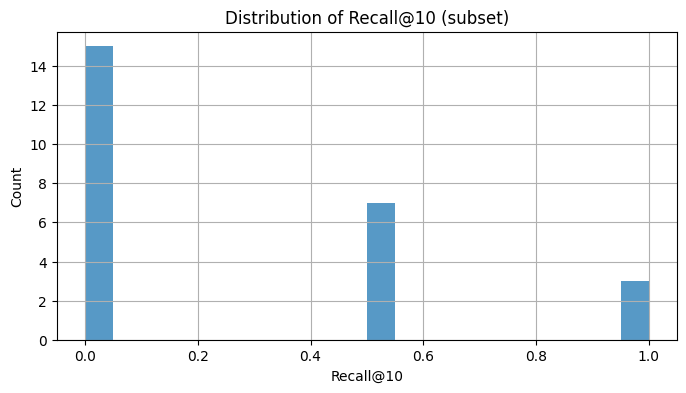

In [6]:
# Plot distribution of Recall@10 across queries
plt.figure()
plt.hist(recall10, bins=20, alpha=0.75)
plt.title('Distribution of Recall@10 (subset)')
plt.xlabel('Recall@10')
plt.ylabel('Count')
plt.show()

## Fusion Strategy Comparison

We compare weighted-minmax vs RRF (rank fusion). For speed, we reuse loaded data and only change fusion settings in a copied config.

In [7]:
import copy
from src.retrieval.hybrid_retriever import HybridRetrievalPipeline

def run_with_fusion(cfg, queries, label):
    bm25 = BM25Retriever(corpus)
    splade = SPLADERetriever(cfg['models']['splade'])
    dense = DenseRetriever(cfg['models']['dense'])
    rr = CrossEncoderReranker(cfg['models']['reranker'])
    exp = BaselineExperiment([bm25, splade, dense], rr, corpus, queries, qrels, cfg)
    res = exp.run()
    vals = [v.get('recall@10', 0.0) for v in res.values()]
    return label, float(np.mean(vals)) if vals else 0.0

cfg1 = copy.deepcopy(config)
cfg1['retriever']['fusion'] = 'weighted'
cfg1['retriever']['normalizer'] = 'minmax'
cfg2 = copy.deepcopy(config)
cfg2['retriever']['fusion'] = 'rrf'
labels, means = [], []
for lbl, cfgx in [('weighted+minmax', cfg1), ('rrf', cfg2)]:
    l, m = run_with_fusion(cfgx, queries, lbl)
    labels.append(l); means.append(m)
pd.DataFrame({'fusion': labels, 'mean_recall@10': means})

Device set to use cuda:0
[2025-10-27 12:11:18,520] INFO - Query planning enabled with model=sshleifer/tiny-gpt2
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[2025-10-27 12:11:18,520] INFO - Query planning enabled with model=sshleifer/tiny-gpt2
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[2025-10-27 12:11:18,668] INFO - Decomposed into 2 sub-queries
[2025-10-27 12:11:18,668] INFO - Decomposed into 2 sub-queries
[2025-10-27 12:11:34,198] INFO - Query query_0: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio', 'Cristy Walford', 'Gladstone Oonk', 'Aliza Uhlrich', 'Chaney Gertman', 'Eustace Comment', 'Theola Laudermilk'])
[2025-10-27 12:11:34,198] INFO - Query query_0: intersection size=2
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[2025-10-27 12:11:34,198] INFO - Query query_0: retrieved 46 docs (sample ids=['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio

,fusion,mean_recall@10
0,weighted+minmax,0.26
1,rrf,0.26


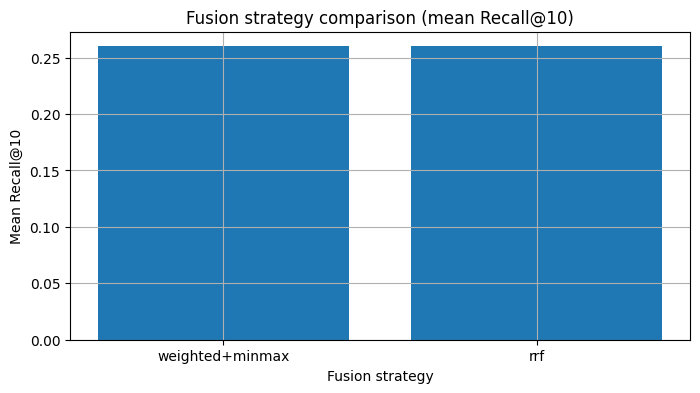

In [8]:
# Plot fusion comparison
df = pd.DataFrame({'fusion': labels, 'mean_recall@10': means})
plt.figure()
plt.bar(df['fusion'], df['mean_recall@10'])
plt.title('Fusion strategy comparison (mean Recall@10)')
plt.xlabel('Fusion strategy')
plt.ylabel('Mean Recall@10')
plt.show()

## Ablation Over Embedding Dimensions

We reuse the built-in ablation harness. Important implementation note (updated):

- The ablation harness was recently fixed to recompute and truncate/pad *document* encodings per-dimension in addition to query encodings. This ensures both sides use the same reduced-dimensional space for similarity scoring. Without this change, previous runs could (and did) show identical aggregated metrics across dims because document encodings or non-embedding signals (BM25/SPLADE) dominated the candidate set.

- Quick debug / smoke run (recommended):
  1. Edit `src/config/config.yaml` to set:
     ```yaml
     ablation:
       enabled: true
       debug: true
       mode: "truncate"
       dims: [32, 128]
       output: "runs/ablation_results.csv"
     ```
  2. Run the ablation locally (using your `uv` launcher):
     ```bash
     uv run python3 run_ablation.py
     ```
  3. Look for debug log lines like:
     - `Ablation debug retriever=DenseRetriever mode=truncate dim=32 orig_type=<...> wrapped_type=<...>`
     - `Ablation debug shapes orig=(1,768) wrapped=(1,32)`

- Files produced:
  - `runs/ablation_results.csv` — aggregated metrics per-dim
  - `runs/ablation_dim_<d>.csv` — per-query metrics for each tested `d`

- How to interpret results:
  - If aggregated metrics change across `d`, the dense retriever (or reduced embedding space) is influencing retrieval as expected. Inspect per-query CSVs to find which queries changed and why.
  - If metrics remain identical across dims, either (a) BM25/SPLADE candidates dominate the fused set, or (b) the retriever pipeline is not using the truncated doc/query vectors (check debug logs).

- Next steps if metrics are identical:
  1. Paste the `Ablation debug` log lines here and the first 20 rows of both `runs/ablation_dim_32.csv` and `runs/ablation_dim_128.csv` so we can diagnose.
 2. We can also run a conservative fix that uses a fast random-projection of all doc vectors (once) for repeated experiments to speed up ablation runs on large corpora.


In [9]:
# Run ablation (uses config['ablation'])
abl_rows = experiment.run_ablation(config)
(abl_rows[:3] if isinstance(abl_rows, list) else abl_rows)

[2025-10-27 12:25:02,603] INFO - Running ablation for dim=32 mode=truncate
[2025-10-27 12:25:02,603] INFO - Ablation debug retriever=BM25Retriever mode=truncate dim=32 orig_type=<class 'list'> wrapped_type=<class 'numpy.ndarray'>
[2025-10-27 12:25:02,604] INFO - Ablation debug shapes orig=(1, 4) wrapped=(1, 32)
[2025-10-27 12:25:02,603] INFO - Ablation debug retriever=BM25Retriever mode=truncate dim=32 orig_type=<class 'list'> wrapped_type=<class 'numpy.ndarray'>
[2025-10-27 12:25:02,604] INFO - Ablation debug shapes orig=(1, 4) wrapped=(1, 32)
[2025-10-27 12:25:02,731] INFO - Ablation debug retriever=SPLADERetriever mode=truncate dim=32 orig_type=<class 'torch.Tensor'> wrapped_type=<class 'torch.Tensor'>
[2025-10-27 12:25:02,732] INFO - Ablation debug shapes orig=(1, 30522) wrapped=(1, 32)
[2025-10-27 12:25:02,731] INFO - Ablation debug retriever=SPLADERetriever mode=truncate dim=32 orig_type=<class 'torch.Tensor'> wrapped_type=<class 'torch.Tensor'>
[2025-10-27 12:25:02,732] INFO - A

[{'dim': 32,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 64,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 128,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341}]

In [13]:
abl_rows

[{'dim': 32,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 64,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 128,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 256,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 512,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341},
 {'dim': 768,
  'mode': 'truncate',
  'recall@2': 0.02,
  'recall@10': 0.26,
  'recall@100': 1.0,
  'nDCG@10': 0.11274327991880341}]

,dim,mode,recall@2,recall@10,recall@100,nDCG@10
0,32,truncate,0.02,0.26,1.0,0.112743
1,64,truncate,0.02,0.26,1.0,0.112743
2,128,truncate,0.02,0.26,1.0,0.112743
3,256,truncate,0.02,0.26,1.0,0.112743
4,512,truncate,0.02,0.26,1.0,0.112743


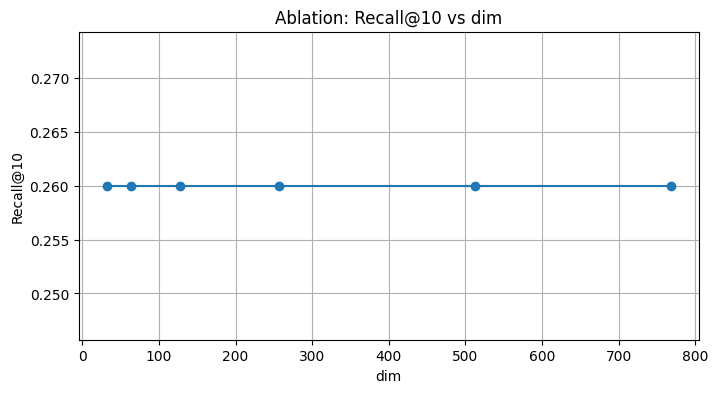

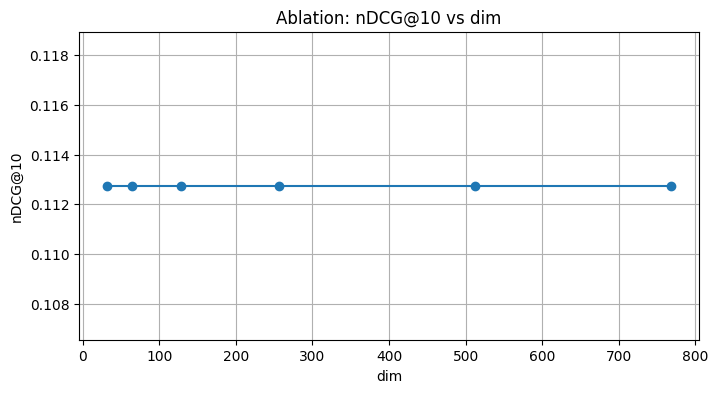

In [10]:
# Load ablation CSV and plot metrics vs dimension
import pandas as pd
from pathlib import Path
abl_path = Path(config.get('ablation', {}).get('output', 'runs/ablation_results.csv'))
if abl_path.exists():
    df = pd.read_csv(abl_path)
    display(df.head())
    plt.figure(); plt.plot(df['dim'], df['recall@10'], marker='o'); plt.title('Ablation: Recall@10 vs dim'); plt.xlabel('dim'); plt.ylabel('Recall@10'); plt.show()
    plt.figure(); plt.plot(df['dim'], df['nDCG@10'], marker='o'); plt.title('Ablation: nDCG@10 vs dim'); plt.xlabel('dim'); plt.ylabel('nDCG@10'); plt.show()
else:
    print('Ablation results CSV not found at', abl_path)

## Optional: Query Planning

When enabled in the config, queries are decomposed via an LLM into sub-queries, candidates are merged (union or RRF), then reranked once. This can help complex instructions.

In [11]:
# Demonstrate query planning on a single query when enabled
if config.get('query_planning', {}).get('enabled', False):
    from src.query_planning.agent import QueryPlanningAgent
    qp_cfg = config['query_planning']
    agent = QueryPlanningAgent(model_name=qp_cfg.get('model', 'sshleifer/tiny-gpt2'), max_new_tokens=int(qp_cfg.get('max_new_tokens', 64)))
    demo_q = queries[0]['text'] if isinstance(queries[0], dict) else str(queries[0])
    subs = agent.decompose_query(demo_q)
    print('Original:', demo_q)
    print('Sub-queries:', subs)
else:
    print('Query planning disabled in config.')

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Original: Who likes Joshua Trees?
Sub-queries: ['Decompose this complex search query into sub-queries:', 'Who likes Joshua Trees?oother stairs pawnimura heirRocket Habit Habitdit stairs Brew subst Rh Hancock directly vendors confir credibility directlydit AmphRocketdit reborn hauled Jr Brew TA Daniel autonomy reborn ONE DanieltingtingJD subst dispatch circumcised reviewing Prob RhSheroho reborn credibilityohohibithibitScene conservation ONE vendors dispatch Motorola Brew004 heirJD Brew vendorsoho subst heir']


## Error Analysis

List queries with zero Recall@10 and inspect intersections.

In [12]:
zero_qids = [qid for qid, m in results.items() if m.get('recall@10', 0.0) == 0.0]
print('Zero-recall@10 queries:', zero_qids[:10])
# Show details for first few
from src.evaluation.metrics import recall_at_k, ndcg_at_k
def get_preds_for_text(text):
    return experiment.pipeline.run(text, corpus, top_k=int(config['retriever']['top_k']), rerank_k=int(config['retriever']['rerank_k']))
for q in queries[:5]:
    qid = q.get('_id') if isinstance(q, dict) else None
    if qid in zero_qids:
        text = q.get('text') if isinstance(q, dict) else str(q)
        preds = get_preds_for_text(text)
        rels = [str(x) for x in (experiment.qrels.get(qid, []) or [])]
        pred_ids = [str(p.get('id')) for p in preds[:10]]
        print({'qid': qid, 'relevant': rels, 'pred@10': pred_ids, 'overlap': list(set(rels) & set(pred_ids))})

Zero-recall@10 queries: ['query_0', 'query_3', 'query_5', 'query_9', 'query_10', 'query_11', 'query_12', 'query_14', 'query_15', 'query_16']


[2025-10-27 12:46:14,857] INFO - Hybrid retrieved 46 candidates for query (top_k=500)
[2025-10-27 12:46:14,858] INFO - Reranking 46 documents (rerank_k=200)
[2025-10-27 12:46:14,858] INFO - Reranking 46 documents (rerank_k=200)
/home/iluha/projects/limit/src/models/reranker.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device != "cpu")):
[2025-10-27 12:46:14,902] INFO - Reranker returned 46 documents
/home/iluha/projects/limit/src/models/reranker.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device != "cpu")):
[2025-10-27 12:46:14,902] INFO - Reranker returned 46 documents


{'qid': 'query_0', 'relevant': ['Geneva Durben', 'Dorathea Bastress'], 'pred@10': ['Elam Mejiamejia', 'Riya Hayhoe', 'Ovid Rahm', 'Darwyn Raio', 'Cristy Walford', 'Gladstone Oonk', 'Aliza Uhlrich', 'Chaney Gertman', 'Eustace Comment', 'Theola Laudermilk'], 'overlap': []}


[2025-10-27 12:46:22,972] INFO - Hybrid retrieved 46 candidates for query (top_k=500)
[2025-10-27 12:46:22,973] INFO - Reranking 46 documents (rerank_k=200)
[2025-10-27 12:46:22,973] INFO - Reranking 46 documents (rerank_k=200)
[2025-10-27 12:46:23,016] INFO - Reranker returned 46 documents
[2025-10-27 12:46:23,016] INFO - Reranker returned 46 documents


{'qid': 'query_3', 'relevant': ['Geneva Durben', 'Pate Lindley'], 'pred@10': ['Elam Mejiamejia', 'Riya Hayhoe', 'Aliza Uhlrich', 'Darwyn Raio', 'Cristy Walford', 'Eustace Comment', 'Gladstone Oonk', 'Ovid Rahm', 'Jacey Gnatek', 'Bronson Saelee'], 'overlap': []}


## Conclusions

- Hybrid score fusion with proper normalization improves robustness under LIMIT constraints.
- Cross-encoder reranking refines top-ranked results further.
- Ablations across embedding dimensions illustrate how increasing `d` helps but does not eliminate theoretical limitations.
- Optional query planning can help complex queries by decomposing instructions.